In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *
from diffSPH.util import print_tensor_gpu_memory_recursive

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [ ]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# device = torch.device('cpu')
dtype = torch.float32
L = 2
dim = 3
nx = 2048

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(2, dim)
print(f"Target neighbors: {targetNeighbors}")


Target neighbors: 268.082573106329


In [7]:
N_H_2 = [n_h_to_nH(2, d) for d in range(1, 4)]
N_H_4 = [n_h_to_nH(4, d) for d in range(1, 4)]

for d in range(1, 4):
    print(f"Dim {d}: N_H(2) = {N_H_2[d-1]}, N_H(4) = {N_H_4[d-1]}")

Dim 1: N_H(2) = 4.0, N_H(4) = 8.0
Dim 2: N_H(2) = 12.566370614359172, N_H(4) = 50.26548245743669
Dim 3: N_H(2) = 33.510321638291124, N_H(4) = 268.082573106329


Min n_x: 8 Max n_x: 4096


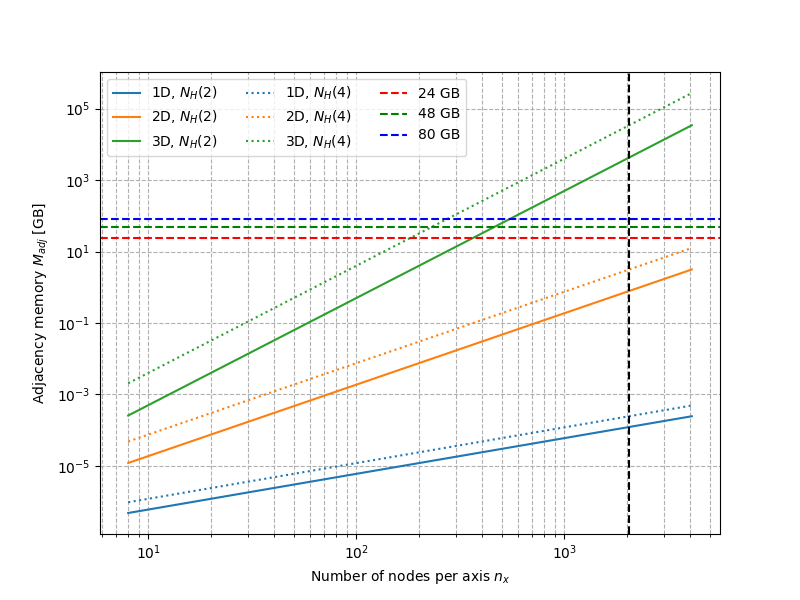

In [ ]:
import numpy as np
m = lambda n_x, d, N_H: 16 * (n_x ** d) * N_H / (1024 ** 3)  # in GB

n_x = np.logspace(3, 12, 100, base =2 , dtype=int)
print(f"Min n_x: {n_x[0]} Max n_x: {n_x[-1]}")

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(8, 6))
plt.plot(n_x, m(n_x, 1, N_H_2[0]), label = "1D, $N_H(2)$", color=colors[0])
plt.plot(n_x, m(n_x, 2, N_H_2[1]), label = "2D, $N_H(2)$", color=colors[1])
plt.plot(n_x, m(n_x, 3, N_H_2[2]), label = "3D, $N_H(2)$", color=colors[2])
plt.plot(n_x, m(n_x, 1, N_H_4[0]), label = "1D, $N_H(4)$", ls = ':', color=colors[0])
plt.plot(n_x, m(n_x, 2, N_H_4[1]), label = "2D, $N_H(4)$", ls = ':', color=colors[1])
plt.plot(n_x, m(n_x, 3, N_H_4[2]), label = "3D, $N_H(4)$", ls = ':', color=colors[2])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of nodes per axis $n_x$")
plt.ylabel("Adjacency memory $M_{adj}$ [GB]")
plt.axhline(y = 24, color = 'r', linestyle = '--', label = "24 GB")
plt.axhline(y = 48, color = 'g', linestyle = '--', label = "48 GB")
plt.axhline(y = 80, color = 'b', linestyle = '--', label = "80 GB")
plt.axvline(x = 2048, color = 'k', linestyle = '--')

plt.legend(ncols=3)
plt.grid(True, which="both", ls="--")

In [28]:
m_node = lambda n_x, d, layers, heads, tokens, mlp_ratio: 4 * (n_x ** d) * layers * (heads * tokens * (4 + mlp_ratio)) / (1024 ** 3)  # in GB

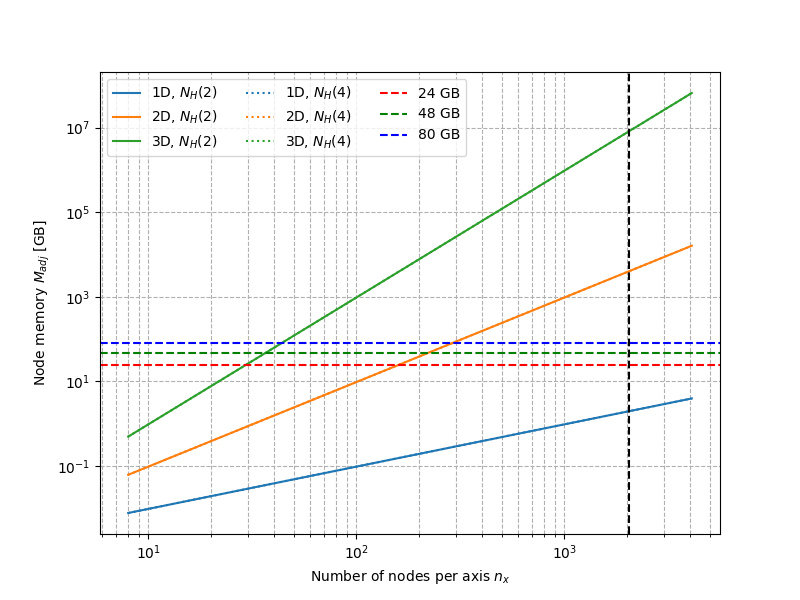

In [35]:
layers = 12
heads = 6
tokens = 64
mlp_ratio = 4

layers = 28
heads = 16
tokens = 72
mlp_ratio = 4

plt.figure(figsize=(8, 6))
plt.plot(n_x, m_node(n_x, 1, layers, heads, tokens, mlp_ratio), label = "1D, $N_H(2)$", color=colors[0])
plt.plot(n_x, m_node(n_x, 2, layers, heads, tokens, mlp_ratio), label = "2D, $N_H(2)$", color=colors[1])
plt.plot(n_x, m_node(n_x, 3, layers, heads, tokens, mlp_ratio), label = "3D, $N_H(2)$", color=colors[2])
plt.plot(n_x, m_node(n_x, 1, layers, heads, tokens, mlp_ratio), label = "1D, $N_H(4)$", ls = ':', color=colors[0])
plt.plot(n_x, m_node(n_x, 2, layers, heads, tokens, mlp_ratio), label = "2D, $N_H(4)$", ls = ':', color=colors[1])
plt.plot(n_x, m_node(n_x, 3, layers, heads, tokens, mlp_ratio), label = "3D, $N_H(4)$", ls = ':', color=colors[2])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of nodes per axis $n_x$")
plt.ylabel("Node memory $M_{adj}$ [GB]")
plt.axhline(y = 24, color = 'r', linestyle = '--', label = "24 GB")
plt.axhline(y = 48, color = 'g', linestyle = '--', label = "48 GB")
plt.axhline(y = 80, color = 'b', linestyle = '--', label = "80 GB")
plt.axvline(x = 2048, color = 'k', linestyle = '--')

plt.legend(ncols=3)
plt.grid(True, which="both", ls="--")

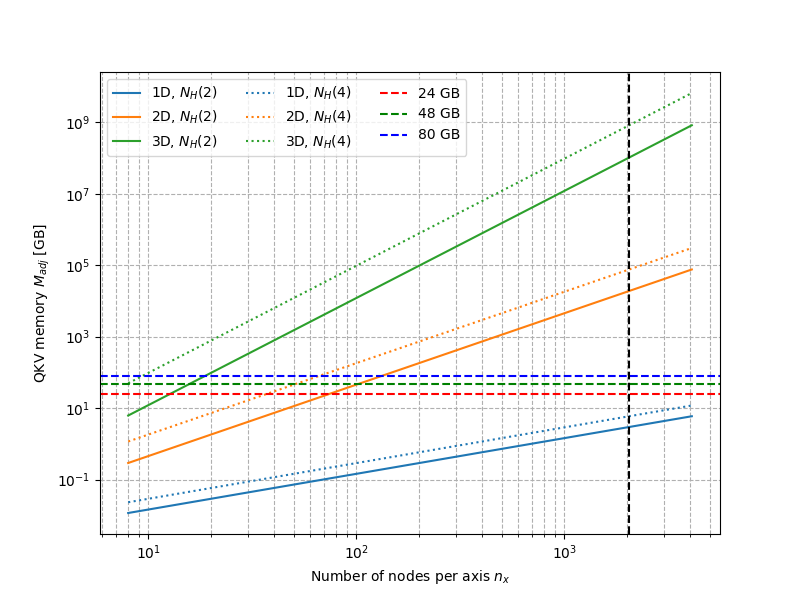

In [34]:
layers = 12
heads = 6
tokens = 64
mlp_ratio = 4

layers = 28
heads = 16
tokens = 72
mlp_ratio = 4

m_qkv = lambda layers, n_x, d, heads, tokens, N_H: layers * 3 * 4 * (n_x ** d) * heads * tokens * N_H / (1024 ** 3)  # in GB

plt.figure(figsize=(8, 6))
plt.plot(n_x, m_qkv(layers, n_x, 1, heads, tokens, N_H_2[0]), label = "1D, $N_H(2)$", color=colors[0])
plt.plot(n_x, m_qkv(layers, n_x, 2, heads, tokens, N_H_2[1]), label = "2D, $N_H(2)$", color=colors[1])
plt.plot(n_x, m_qkv(layers, n_x, 3, heads, tokens, N_H_2[2]), label = "3D, $N_H(2)$", color=colors[2])
plt.plot(n_x, m_qkv(layers, n_x, 1, heads, tokens, N_H_4[0]), label = "1D, $N_H(4)$", ls = ':', color=colors[0])
plt.plot(n_x, m_qkv(layers, n_x, 2, heads, tokens, N_H_4[1]), label = "2D, $N_H(4)$", ls = ':', color=colors[1])
plt.plot(n_x, m_qkv(layers, n_x, 3, heads, tokens, N_H_4[2]), label = "3D, $N_H(4)$", ls = ':', color=colors[2])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of nodes per axis $n_x$")
plt.ylabel("QKV memory $M_{adj}$ [GB]")
plt.axhline(y = 24, color = 'r', linestyle = '--', label = "24 GB")
plt.axhline(y = 48, color = 'g', linestyle = '--', label = "48 GB")
plt.axhline(y = 80, color = 'b', linestyle = '--', label = "80 GB")
plt.axvline(x = 2048, color = 'k', linestyle = '--')

plt.legend(ncols=3)
plt.grid(True, which="both", ls="--")

In [9]:
print_tensor_gpu_memory_recursive(particles, silent = False)
print_tensor_gpu_memory_recursive(particlesLR, silent = False)

positions: 32.00 MB (33554432 bytes) Shape: torch.Size([4194304, 2]) dtype: torch.float32 device: cuda:0
supports: 16.00 MB (16777216 bytes) Shape: torch.Size([4194304]) dtype: torch.float32 device: cuda:0
masses: 16.00 MB (16777216 bytes) Shape: torch.Size([4194304]) dtype: torch.float32 device: cuda:0
densities: 16.00 MB (16777216 bytes) Shape: torch.Size([4194304]) dtype: torch.float32 device: cuda:0
Total GPU memory used by torch.Tensors: 80.00 MB (83886080 bytes)
positions: 8.00 MB (8388608 bytes) Shape: torch.Size([1048576, 2]) dtype: torch.float32 device: cuda:0
supports: 4.00 MB (4194304 bytes) Shape: torch.Size([1048576]) dtype: torch.float32 device: cuda:0
masses: 4.00 MB (4194304 bytes) Shape: torch.Size([1048576]) dtype: torch.float32 device: cuda:0
densities: 4.00 MB (4194304 bytes) Shape: torch.Size([1048576]) dtype: torch.float32 device: cuda:0
Total GPU memory used by torch.Tensors: 20.00 MB (20971520 bytes)


20971520

In [10]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

In [11]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr
import numpy as np


mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]
particleState = wcstateToState(particles)
particleStateLR = wcstateToState(particlesLR)

k_ = 2
u_mag = 1.0


ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

particleState.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * particleState.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * particleState.positions[:,1] + phaseShift_y)
particleState.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * particleState.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * particleState.positions[:,1] + phaseShift_y)


particleStateLR.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * particleStateLR.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * particleStateLR.positions[:,1] + phaseShift_y)
particleStateLR.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * particleStateLR.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * particleStateLR.positions[:,1] + phaseShift_y)

In [12]:
neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particlesLR, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
# print_tensor_gpu_memory_recursive(sparseNeighborhood_, silent = False)
print_tensor_gpu_memory_recursive(neighborhood, silent = False)

torch.cuda.empty_cache()   

points_a:
  positions: 32.00 MB (33554432 bytes) Shape: torch.Size([4194304, 2]) dtype: torch.float32 device: cuda:0
  supports: 16.00 MB (16777216 bytes) Shape: torch.Size([4194304]) dtype: torch.float32 device: cuda:0
  Total GPU memory used by torch.Tensors: 48.00 MB (50331648 bytes)
points_b:
  positions: 8.00 MB (8388608 bytes) Shape: torch.Size([1048576, 2]) dtype: torch.float32 device: cuda:0
  supports: 4.00 MB (4194304 bytes) Shape: torch.Size([1048576]) dtype: torch.float32 device: cuda:0
  Total GPU memory used by torch.Tensors: 12.00 MB (12582912 bytes)
domain:
  min: 0.00 MB (8 bytes) Shape: torch.Size([2]) dtype: torch.float32 device: cuda:0
  max: 0.00 MB (8 bytes) Shape: torch.Size([2]) dtype: torch.float32 device: cuda:0
  periodic: 0.00 MB (2 bytes) Shape: torch.Size([2]) dtype: torch.bool device: cuda:0
  Total GPU memory used by torch.Tensors: 0.00 MB (18 bytes)
accelerationStructure:
  sortedPositions: 8.00 MB (8388608 bytes) Shape: torch.Size([1048576, 2]) dtype: 

In [13]:
neighborhoodLR, sparseNeighborhoodLR_ = buildNeighborhood(particlesLR, particles, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
print_tensor_gpu_memory_recursive(neighborhoodLR, silent = False)

points_a:
  positions: 8.00 MB (8388608 bytes) Shape: torch.Size([1048576, 2]) dtype: torch.float32 device: cuda:0
  supports: 4.00 MB (4194304 bytes) Shape: torch.Size([1048576]) dtype: torch.float32 device: cuda:0
  Total GPU memory used by torch.Tensors: 12.00 MB (12582912 bytes)
points_b:
  positions: 32.00 MB (33554432 bytes) Shape: torch.Size([4194304, 2]) dtype: torch.float32 device: cuda:0
  supports: 16.00 MB (16777216 bytes) Shape: torch.Size([4194304]) dtype: torch.float32 device: cuda:0
  Total GPU memory used by torch.Tensors: 48.00 MB (50331648 bytes)
domain:
  min: 0.00 MB (8 bytes) Shape: torch.Size([2]) dtype: torch.float32 device: cuda:0
  max: 0.00 MB (8 bytes) Shape: torch.Size([2]) dtype: torch.float32 device: cuda:0
  periodic: 0.00 MB (2 bytes) Shape: torch.Size([2]) dtype: torch.bool device: cuda:0
  Total GPU memory used by torch.Tensors: 0.00 MB (18 bytes)
accelerationStructure:
  sortedPositions: 32.00 MB (33554432 bytes) Shape: torch.Size([4194304, 2]) dtype

1072726080

In [16]:
512**3

134217728

In [14]:
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)
neighborsLR = computeNeighborhoodStates(particleStateLR, sparseNeighborhoodLR_, mode_str, kernel, kernel, True, False, False)
numNeighborsLR = coo_to_csr(neighborsLR.neighbors).rowEntries
# particleStateLR.densities = computeDensity(particleStateLR, kernel, neighborsLR.get('noghost'), SupportScheme.Gather, config)

print('Number of neighbors:', numNeighbors.shape, numNeighbors)
print('Number of neighbors LR:', numNeighborsLR.shape, numNeighborsLR)

Number of neighbors: torch.Size([4194304]) tensor([13, 13, 13,  ..., 13, 13, 13], device='cuda:0')
Number of neighbors LR: torch.Size([1048576]) tensor([52, 52, 52,  ..., 52, 52, 52], device='cuda:0')


In [15]:
print_tensor_gpu_memory_recursive(neighbors, silent = False)
print_tensor_gpu_memory_recursive(neighborsLR, silent = False)

neighbors:
  row: 416.00 MB (436207616 bytes) Shape: torch.Size([54525952]) dtype: torch.int64 device: cuda:0
  col: 416.00 MB (436207616 bytes) Shape: torch.Size([54525952]) dtype: torch.int64 device: cuda:0
  points_a:
    positions: 32.00 MB (33554432 bytes) Shape: torch.Size([4194304, 2]) dtype: torch.float32 device: cuda:0
    supports: 16.00 MB (16777216 bytes) Shape: torch.Size([4194304]) dtype: torch.float32 device: cuda:0
    Total GPU memory used by torch.Tensors: 48.00 MB (50331648 bytes)
  points_b:
    positions: 8.00 MB (8388608 bytes) Shape: torch.Size([1048576, 2]) dtype: torch.float32 device: cuda:0
    supports: 4.00 MB (4194304 bytes) Shape: torch.Size([1048576]) dtype: torch.float32 device: cuda:0
    Total GPU memory used by torch.Tensors: 12.00 MB (12582912 bytes)
  domain:
    min: 0.00 MB (8 bytes) Shape: torch.Size([2]) dtype: torch.float32 device: cuda:0
    max: 0.00 MB (8 bytes) Shape: torch.Size([2]) dtype: torch.float32 device: cuda:0
    periodic: 0.00 MB

4643094546

In [ ]:
import torch
import collections

from diffSPH.util import print_tensor_gpu_memory_recursive

print('Sparse Neighborhood:')
print_tensor_gpu_memory_recursive(sparseNeighborhood_)
print('Sparse Neighborhood LR:')
print_tensor_gpu_memory_recursive(sparseNeighborhoodLR_)

print('Neighborhood:')
print_tensor_gpu_memory_recursive(neighborhood)
print('Neighborhood LR:')
print_tensor_gpu_memory_recursive(neighborhoodLR)

print("neighbors:")
print_tensor_gpu_memory_recursive(neighbors)
print("neighbors LR:")
print_tensor_gpu_memory_recursive(neighborsLR)

Sparse Neighborhood:
	points_a:  Total GPU memory used by torch.Tensors: 3.00 MB (3145728 bytes)
	points_b:  Total GPU memory used by torch.Tensors: 0.75 MB (786432 bytes)
	domain:  Total GPU memory used by torch.Tensors: 0.00 MB (18 bytes)
Total GPU memory used by torch.Tensors: 211.75 MB (222035986 bytes)
Sparse Neighborhood LR:
	points_a:  Total GPU memory used by torch.Tensors: 0.75 MB (786432 bytes)
	points_b:  Total GPU memory used by torch.Tensors: 3.00 MB (3145728 bytes)
	domain:  Total GPU memory used by torch.Tensors: 0.00 MB (18 bytes)
Total GPU memory used by torch.Tensors: 395.75 MB (414973970 bytes)
Neighborhood:
	points_a:  Total GPU memory used by torch.Tensors: 3.00 MB (3145728 bytes)
	points_b:  Total GPU memory used by torch.Tensors: 0.75 MB (786432 bytes)
	domain:  Total GPU memory used by torch.Tensors: 0.00 MB (18 bytes)
	accelerationStructure:  Total GPU memory used by torch.Tensors: 2.08 MB (2179118 bytes)
	fullAdjacency:  Total GPU memory used by torch.Tensors:

1148977170

In [5]:
# particleState = wcstateToState(particles)
# neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)

# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

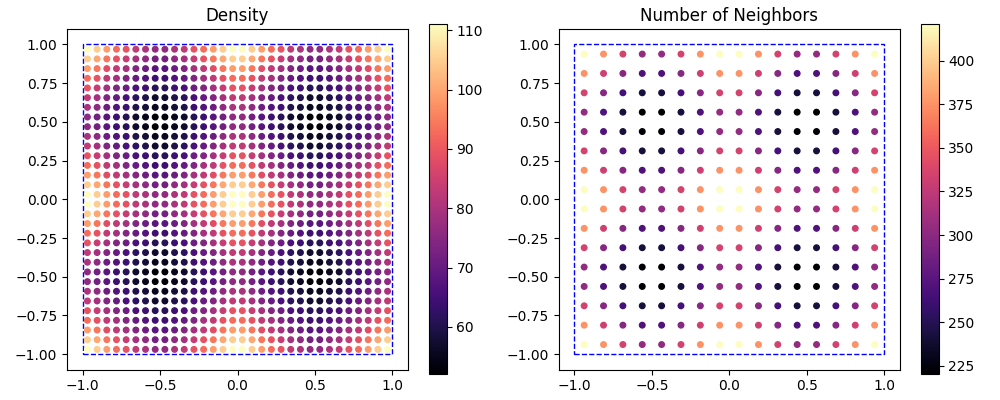

In [6]:
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleStateLR, config['domain'], numNeighborsLR,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [7]:
from ml import *

In [8]:
inputFeatures = torch.cat([
    particleState.velocities,
    torch.ones_like(particleState.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

inputFeaturesLR = torch.cat([
    particleStateLR.velocities,
    torch.ones_like(particleStateLR.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

gt = particleState.densities.to(device)[:, None]  # ground truth densities

In [9]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

In [10]:
# inputEncoder = buildMLPwDict({
#  'inputFeatures': inputFeatures.shape[1],
#  'output' : 48,
#  'activation': 'celu',
#  'layout': [hiddenMLPSize] * inputEncoderLayers,
#  'norm': False,
#  'bias': False,
# }
# ).to(device)

# numberOfParameters = sum(p.numel() for p in inputEncoder.parameters())
# print(f'Number of parameters in input encoder: {numberOfParameters}')

# for i, layer in enumerate(inputEncoder):
#     print(f'Layer {i}: {layer}')

# encodedInput = inputEncoder(inputFeatures)
# encodedInputLR = inputEncoder(inputFeaturesLR)

In [11]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)


print(neighbors.neighbors.row.shape)
filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
# filteredNeighborhood = neighbors.neighbors

print(filteredNeighborhood.row.shape)


h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
sparse_edge_attr = xij_ / h_i[:,None]

print('Maximum distance: ', (rij / h_i).max().item())


# minD = domain.min
# maxD = domain.max
# periodicity = domain.periodic

# dense_xij = (particleState.positions[:,None] - particleState.positions)
# dense_mod_xij = torch.stack([dense_xij.reshape(nx**4, 2)[:,i] if not periodic_i else mod(dense_xij.reshape(nx**4, 2)[:,i], minD[i], maxD[i]) for i, periodic_i in enumerate(periodicity)], dim = -1).reshape(nx**2, nx**2, dim)

# print('dense_xij', dense_mod_xij.shape)
# print(dense_mod_xij.min())

torch.Size([78160])
torch.Size([16256])
Maximum distance:  0.9519716501235962


In [12]:
torch.cuda.empty_cache()

In [13]:
from util import *
# adjacency = buildDenseNeighborhood(particleState, domain)
adjacency = buildSparseNeighborhood(filteredNeighborhood)

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [15]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency, normalize = False, mode = 'gather')

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 11
multiHeads = 3
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = edge_attr.shape[-1]

node_attr = (inputFeatures.reshape(1, -1, inputFeatures.shape[-1]), inputFeaturesLR.reshape(1, -1, inputFeaturesLR.shape[-1]))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 5
node_attr_batched = (inputFeatures.repeat(bs, 1, 1), inputFeaturesLR.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleStateLR.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

node_positions = (particleState.positions.reshape(1, -1, particleState.positions.shape[-1]).repeat(bs, 1, 1), particleStateLR.positions.reshape(1, -1, particleStateLR.positions.shape[-1]).repeat(bs, 1, 1 ))  # Reshape to [B, N, D] for batch processing

print('node_positions shape:', node_positions[0].shape, node_positions[1].shape)

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)


e_ij = torch.cat([edge_attr_batched, torch.linalg.norm(edge_attr_batched, dim=-1, keepdim=True),], dim=-1)
print(e_ij.shape)

spatial_features = edge_attr_batched
# rpb_features = basisEncoder(spatial_features).squeeze(0)

from layers.windows import getWindowFunction

windowValues = getWindowFunction('cubicSpline', norm = None)(torch.linalg.norm(edge_attr_batched, dim=-1))

edge_attr shape: torch.Size([16256, 2])
edge_index shape: torch.Size([2, 16256])
node_attr shape: torch.Size([1, 1024, 3]) torch.Size([1, 256, 3])
Edge indices for batch 0: torch.Size([2, 16256])
Edge indices for batch 1: torch.Size([2, 16256])
Edge indices for batch 2: torch.Size([2, 16256])
Edge indices for batch 3: torch.Size([2, 16256])
Edge indices for batch 4: torch.Size([2, 16256])
node_positions shape: torch.Size([5, 1024, 2]) torch.Size([5, 256, 2])
node_attr_batched shape: torch.Size([5, 1024, 3]) torch.Size([5, 256, 3])
edge_attr_batched shape: torch.Size([81280, 2])
edge_indices_batched shape: torch.Size([2, 81280])
torch.Size([81280, 3])


In [16]:
from blocks.basicEncoder import BasicEncoder

encoder = BasicEncoder(
    input_dim = node_attr_batched[0].shape[-1],
    output_dim = transformerFeatures * multiHeads,
    hidden_layers = 2,
    latent_dim = 32,
    verbose = False,
)
decoder = BasicEncoder(
    input_dim = transformerFeatures * multiHeads,
    output_dim = 1,
    hidden_layers = 2,
    latent_dim = 32,
    verbose = False,
)

In [17]:
encodedNodes = (encoder(node_attr_batched[0], inputPositions=node_positions[0]),
                encoder(node_attr_batched[1], inputPositions=node_positions[1])
            )

decodedNodes = (decoder(encodedNodes[0]), decoder(encodedNodes[1]))

In [18]:
from blocks.common import CommonConfiguration
import copy

baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=encodedNodes[0].shape[-1],
    token_output_dim=encodedNodes[0].shape[-1],
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=2,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=2,
    mlp_latent_dim = 32,
    mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)
baseConfig.use_encoder=True
baseConfig.use_decoder=True
baseConfig.token_input_dim=node_attr_batched[0].shape[-1]
baseConfig.token_output_dim=1
baseConfig.ffn_skip_last = True

In [19]:
from blocks.basicTransformer import BasicTransformer

transformerModel = BasicTransformer(
    config = baseConfig,
    transformer_features = transformerFeatures,
    attention_heads = multiHeads,

    verbose = False,
).to(device)

transformerModelNoEncoders = BasicTransformer(
    config = baseConfigNoEncoders,
    transformer_features = transformerFeatures,
    attention_heads = multiHeads,

    verbose = False,
).to(device)


In [20]:
outA = transformerModel(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(transformerModelNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))

In [21]:
from blocks.ContinuousConvolution import CConvModel, BasicCConvLayer

cconvModel = CConvModel(
    config=baseConfig,

    verbose = False,
).to(device)

cconvModelNoEncoders = CConvModel(
    config=baseConfigNoEncoders,

    verbose = False,
).to(device)


In [22]:
outA = cconvModel(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(cconvModelNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))

In [23]:
from blocks.GNN import GNNModel

gnn = GNNModel(
    config = baseConfig,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

gnnNoEncoders = GNNModel(
    config = baseConfigNoEncoders,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

In [24]:
outA = gnn(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(gnnNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))